In [ ]:
# POC 2 - Using LangChain
# Build a system which can convert one programming language code to another

from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model

# Initialize Model
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# Prompt Templates

generate_prompt = PromptTemplate(
    input_variables=["source_lang", "target_lang", "source_code"],
    template="""
Convert the following {source_lang} code into {target_lang} code.

Requirements:
- Must be executable
- Correct syntax
- Include imports if needed
- Only output code, no explanation

Source Code:
{source_code}
"""
)

validate_prompt = PromptTemplate(
    input_variables=["target_lang", "converted_code"],
    template="""
Check if this {target_lang} code is correct and executable.

Code:
{converted_code}

Reply ONLY:
VALID
or
INVALID: <reason>
"""
)

correct_prompt = PromptTemplate(
    input_variables=["target_lang", "validation_result", "converted_code"],
    template="""
Fix this {target_lang} code.

Error:
{validation_result}

Code:
{converted_code}

Return corrected executable code only.
"""
)

# Chains (using LCEL)

generate_chain = generate_prompt | llm
validate_chain = validate_prompt | llm
correct_chain  = correct_prompt  | llm

# Core Logic

def run_code_converter(source_code, source_lang, target_lang, max_retries=3):

    # Step 1: Generate
    print("Generating converted code...")
    response = generate_chain.invoke({
        "source_lang": source_lang,
        "target_lang": target_lang,
        "source_code": source_code
    })
    converted_code = response.content

    retry = 0

    while retry < max_retries:

        # Step 2: Validate
        print(f"\nValidating... (Attempt {retry + 1})")
        val_response = validate_chain.invoke({
            "target_lang": target_lang,
            "converted_code": converted_code
        })
        validation_result = val_response.content
        print("Valid/Invalid >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> ", validation_result)

        # Step 3: Router Logic
        if "VALID" in validation_result:
            print("\nCode is VALID. Stopping.")
            break

        else:
            print("\nCode is INVALID. Attempting correction...")
            # Step 4: Correct
            cor_response = correct_chain.invoke({
                "target_lang": target_lang,
                "validation_result": validation_result,
                "converted_code": converted_code
            })
            converted_code = cor_response.content
            retry += 1

    return converted_code, validation_result


# Run

source_code = """
def add(a, b):
    return a + b

print(add(2,3))
"""

converted_code, validation_result = run_code_converter(
    source_code=source_code,
    source_lang="Python",
    target_lang="Java"
)

# Output

print("\nConverted Code:\n")
print(converted_code)

print("\nValidation Result:\n")
print(validation_result)

In [1]:
# Using LangGraph Build a system which can able to convert one programming language code to another programming language which can be executed

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model


# Define State

class CodeState(TypedDict):
    source_code: str
    source_lang: str
    target_lang: str
    converted_code: str
    validation_result: str
    retry: int


# Initialize Model

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)



E:\EDU_CARE\arg_venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
E:\EDU_CARE\arg_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Code Generator Node

def generate_code(state: CodeState):

    prompt = f"""
    Convert the following {state['source_lang']} code into {state['target_lang']} code.

    Requirements:
    - Must be executable
    - Correct syntax
    - Include imports if needed
    - Only output code, no explanation

    Source Code:
    {state['source_code']}
    """

    response = llm.invoke(prompt)

    state["converted_code"] = response.content

    return state


# Code Validator Node

def validate_code(state: CodeState):

    prompt = f"""
    Check if this {state['target_lang']} code is correct and executable.

    Code:
    {state['converted_code']}

    Reply ONLY:
    VALID
    or
    INVALID: <reason>
    """

    response = llm.invoke(prompt)

    state["validation_result"] = response.content
    print("Valid/Invalid >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> ",state["validation_result"])
    return state


# Self Correction Node

def correct_code(state: CodeState):

    prompt = f"""
    Fix this {state['target_lang']} code.

    Error:
    {state['validation_result']}

    Code:
    {state['converted_code']}

    Return corrected executable code only.
    """

    response = llm.invoke(prompt)

    state["converted_code"] = response.content

    state["retry"] += 1

    return state


# Router Logic

def router(state: CodeState):

    if "VALID" in state["validation_result"]:
        return "end"

    elif state["retry"] >= 3:
        return "end"

    else:
        return "correct"


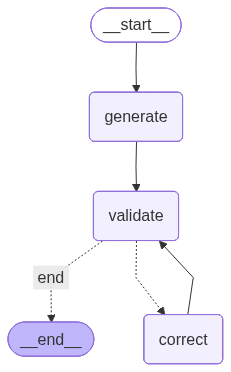

In [3]:
#  Build Graph
graph = StateGraph(CodeState)

graph.add_node("generate", generate_code)
graph.add_node("validate", validate_code)
graph.add_node("correct", correct_code)

graph.add_edge(START, "generate")

graph.add_edge("generate", "validate")

graph.add_conditional_edges(
    "validate",
    router,
    {
        "correct": "correct",
        "end": END
    }
)

graph.add_edge("correct", "validate")

app = graph.compile()

# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))


In [4]:
# Run the prompt

input_state = {
    "source_code": """
def add(a, b):
    return a + b

print(add(2,3))
""",
    "source_lang": "Python",
    "target_lang": "Java",
    "converted_code": "",
    "validation_result": "",
    "retry": 0
}


result = app.invoke(input_state)


#  Output

print("\nConverted Code:\n")
print(result["converted_code"])

print("\nValidation Result:\n")
print(result["validation_result"])


Valid/Invalid >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>  VALID

Converted Code:

```java
public class Main {
    public static void main(String[] args) {
        System.out.println(add(2, 3));
    }

    public static int add(int a, int b) {
        return a + b;
    }
}
```

Validation Result:

VALID
